<a href="https://colab.research.google.com/github/DamianArtur/KISD_ML/blob/main/ML_fit_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import collections as collections
from scipy import stats
from scipy import special
from scipy import integrate
from scipy import optimize

#  Template for the ML fit to data


In [64]:
def gauss(x, mu, sigma):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(x-mu)*(x-mu)/(2*sigma*sigma))


def decay(x, tau):
    return np.exp(-x/tau) / tau



In [65]:
def logL(mus, data, xmin=0, xmax=99, tau0=5.0, mu0=10.0, sigma0=3.0):

    N = len(data)
    Ns = mus
    Nb = N - Ns

    integrals = integrate.quad(gauss, xmin, xmax, args=(mu0, sigma0))
    scales = 1 / integrals[0]

    integralb = integrate.quad(decay, xmin, xmax, args=(tau0,))
    scaleb = 1 / integralb[0]

    ll = 0.0

    for x in data:
        fs = scales * gauss(x, mu0, sigma0)
        fb = scaleb * decay(x, tau0)

        pdf = (Ns / N) * fs + (Nb / N) * fb

        ll += np.log(pdf)

    return -ll

In [66]:
# Define known constants
tau = 5.0
mu = 10.0
sigma = 3.0

# Define some auxiliary parameters
plow = 0.0
phig = 40.0
ndistr = 1000

# Deafine the histogram
nbins = 10
xrange = 30


x = np.linspace(0, xrange, ndistr)

# Load the raw data from file:
rndy = np.load("raw_data_3_tau5.npy")
nhist = len(rndy)



In [67]:
# Find the p.d.f. normalisation factors for the considered interval (0, xrange)
integrals = integrate.quad(gauss, 0, xrange, args=(mu, sigma))
#print('integrals = ', integrals[0])
scales = 1/integrals[0]
integralb = integrate.quad(decay, 0, xrange, args=(tau,))
#print('integralb = ', integralb[0])
scaleb = 1/integralb[0]

# Histogram the raw data
hy, binsy = np.histogram(rndy, bins=nbins, range=(0.0, xrange) )


In [68]:
# Find the extremum of either logL or chi2
in_guess = [0,]
minimum = optimize.minimize(logL, in_guess, args=(rndy ,0.0, xrange, tau, mu, sigma))
fitted_mus = minimum.x[0]
print('extremum found for mus = ',fitted_mus)



extremum found for mus =  18.294645180711242


In [69]:
# Set dummy uncertainties
sigma_neg = fitted_mus-10
sigma_pos = fitted_mus+10
#  Estimate the error:
pl = np.linspace(plow, phig, ndistr)
ll_array = []
for xx in pl:
   ll_array.append(logL(xx, rndy, 0.0, xrange, tau, mu, sigma))

ll_array = np.array(ll_array)

ll_min = np.min(ll_array)
idx_min = np.argmin(ll_array)
Ns_best = pl[idx_min]

level = ll_min + 0.5

sigma_neg = Ns_best
sigma_pos = Ns_best

for i in range(idx_min, 0, -1):
    if ll_array[i] > level:
        sigma_neg = pl[i]
        break

for i in range(idx_min, len(pl)):
    if ll_array[i] > level:
        sigma_pos = pl[i]
        break

print("-sigma = %2.3f,  +sigma = %2.3f"%(sigma_neg, sigma_pos))



-sigma = 10.971,  +sigma = 25.986


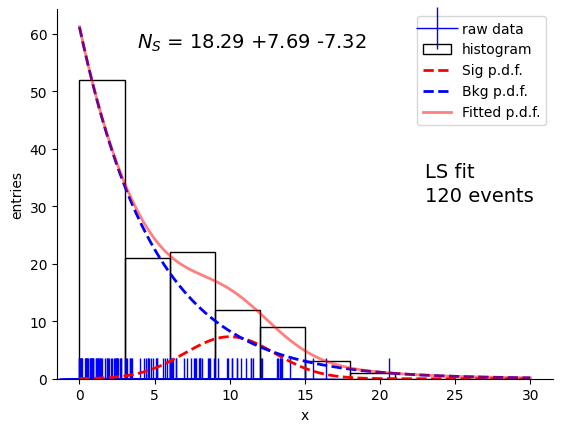

In [70]:
# fitted p.d.f.:
y = (fitted_mus/nhist*scales*gauss(x, mu, sigma)+(nhist-fitted_mus)/nhist*scaleb*decay(x, tau))
ys = (fitted_mus/nhist*scales*gauss(x, mu, sigma))
yb = ((nhist-fitted_mus)/nhist*scaleb*decay(x, tau))

fig, ax = plt.subplots()

ax.plot(rndy, np.zeros(rndy.shape), 'b+', ms=30, label="raw data")  # rug plot
ax.hist(rndy, bins=nbins, range=(0.0, xrange), fill=False, color='green', label="histogram")  # histogram

ax.plot(x, nhist*xrange*(1/nbins)*ys, 'r', linewidth=2, linestyle='--', label="Sig p.d.f.")
ax.plot(x, nhist*xrange*(1/nbins)*yb, 'b', linewidth=2, linestyle='--', label="Bkg p.d.f.")
ax.plot(x, nhist*xrange*(1/nbins)*y, 'r', alpha=0.5, linewidth=2, linestyle='-', label="Fitted p.d.f.")
#ax.set_ylim(bottom=0)

fig.text(0.70, 0.53, 'LS fit', fontsize=14)
fig.text(0.70, 0.48, '%d events'%nhist, fontsize=14)
fig.text(0.25, 0.80, '$N_S$ = %2.2f +%2.2f -%2.2f'%(fitted_mus,sigma_pos-fitted_mus,fitted_mus-sigma_neg), fontsize=14)
#fig.text(0.25, 0.80, '$N_S$ = %2.2f'%(fitted_mus), fontsize=14)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')

ax.legend(loc=1, fontsize=10)

ax.set_xlabel('x')
ax.set_ylabel('entries')

plt.show()